# A Comparative Analysis of Machine Learning Models for Sales Forecasting Using Big Data


## 1. Import Required Libraries

In [1]:
# Core libraries for data handling
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and model selection
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

# Machine Learning models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Suppress unnecessary warnings for a clean notebook output
import warnings
warnings.filterwarnings("ignore")

## 2. Dataset Loading

In [2]:
# Load the Rossmann Store Sales training dataset
df = pd.read_csv("train.csv", low_memory=False)

# Display first 5 rows to confirm successful loading
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


## 3. Data Inspection

In [3]:
# Check the shape (rows, columns) of the dataset
print("Dataset shape:", df.shape)

Dataset shape: (1017209, 9)


In [4]:
# Check column data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [5]:
# Statistical summary of numerical columns
df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [6]:
# Check for missing values in each column
df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0


In [7]:
# Check unique values of the categorical columns
print("Unique values in StateHoliday:", df["StateHoliday"].unique())
print("Unique values in SchoolHoliday:", df["SchoolHoliday"].unique())
print("Unique values in Promo:", df["Promo"].unique())
print("Unique values in Open:", df["Open"].unique())

Unique values in StateHoliday: ['0' 'a' 'b' 'c']
Unique values in SchoolHoliday: [1 0]
Unique values in Promo: [1 0]
Unique values in Open: [1 0]


In [8]:
# Check for duplicate rows in the dataset
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## 4. Data Processing

In [9]:
# Convert Date column from string to proper datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Confirm the conversion
df["Date"].dtype

dtype('<M8[ns]')

In [10]:
# StateHoliday contains mixed types (0 and string labels); standardize to string
df["StateHoliday"] = df["StateHoliday"].astype(str)

# Confirm cleaned unique values
df["StateHoliday"].unique()

array(['0', 'a', 'b', 'c'], dtype=object)

In [11]:
# Remove rows where the store was closed (Open = 0)
df = df[df["Open"] == 1]

# Confirm new shape after filtering
print("Shape after removing closed-store days:", df.shape)

Shape after removing closed-store days: (844392, 9)


In [12]:
# Reset index after filtering rows
df = df.reset_index(drop=True)

# Final check of cleaned dataset
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


## 5. Exploratory Data Analysis (EDA)

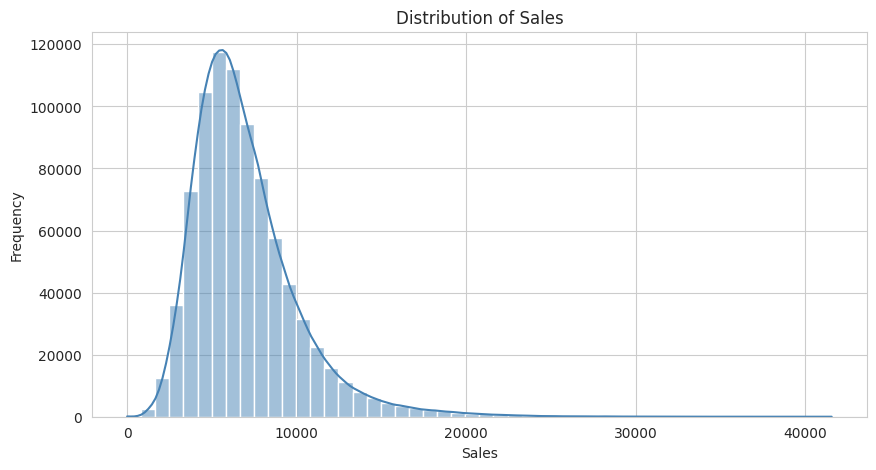

In [13]:
# Graph 1: Distribution of Sales
plt.figure(figsize=(10, 5))
sns.histplot(df["Sales"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

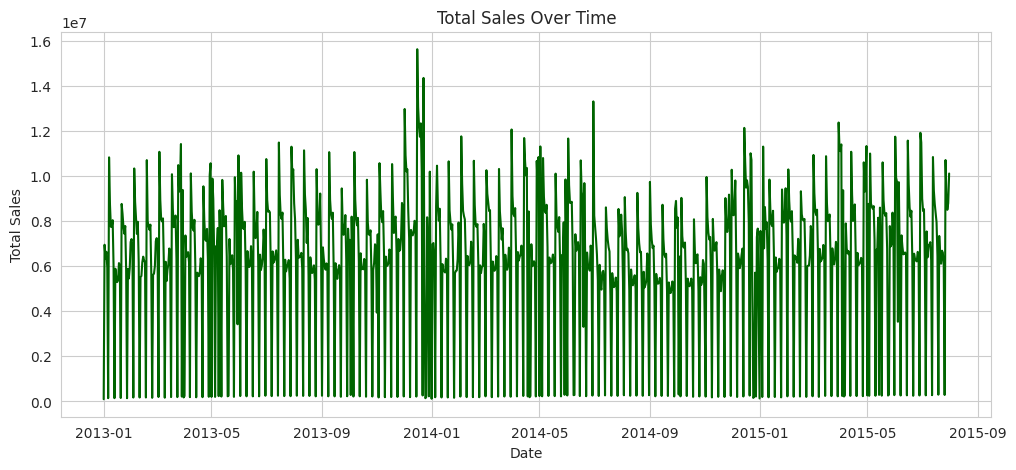

In [14]:
# Graph 2: Average daily total Sales trend over time
daily_sales = df.groupby("Date")["Sales"].sum()
plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index, daily_sales.values, color="darkgreen")
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

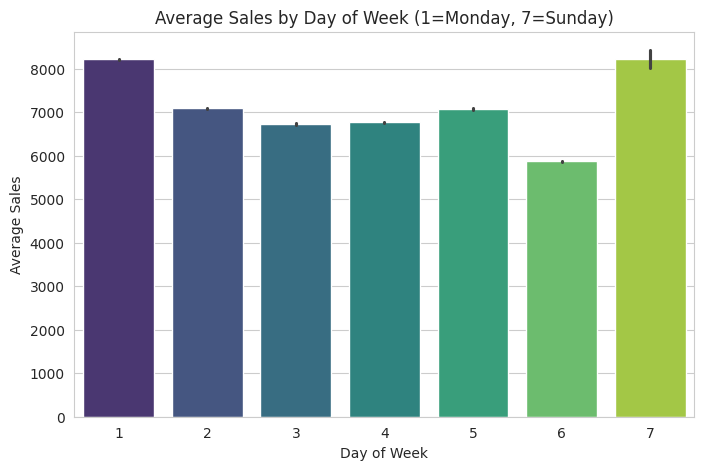

In [15]:
# Graph 3: Average Sales by Day of the Week
plt.figure(figsize=(8, 5))
sns.barplot(x="DayOfWeek", y="Sales", data=df, estimator=np.mean, palette="viridis")
plt.title("Average Sales by Day of Week (1=Monday, 7=Sunday)")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.show()

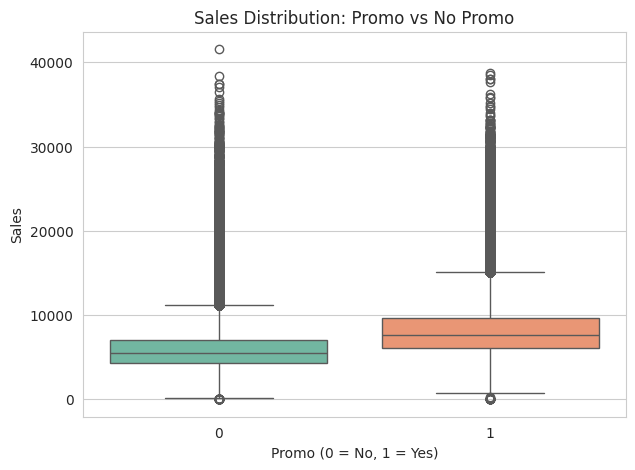

In [16]:
# Graph 4: Effect of Promotion on Sales
plt.figure(figsize=(7, 5))
sns.boxplot(x="Promo", y="Sales", data=df, palette="Set2")
plt.title("Sales Distribution: Promo vs No Promo")
plt.xlabel("Promo (0 = No, 1 = Yes)")
plt.ylabel("Sales")
plt.show()

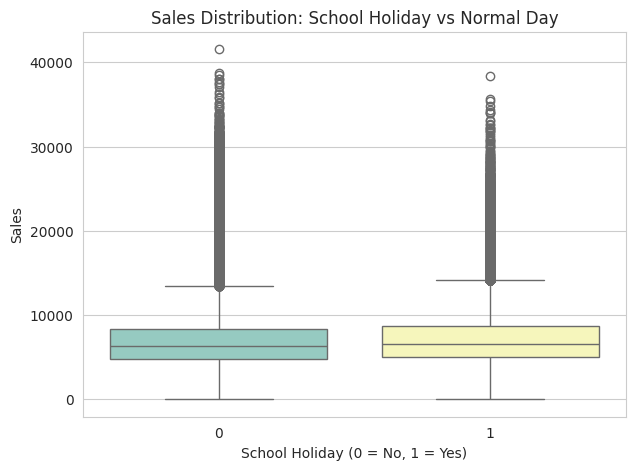

In [17]:
# Graph 5: Effect of School Holiday on Sales
plt.figure(figsize=(7, 5))
sns.boxplot(x="SchoolHoliday", y="Sales", data=df, palette="Set3")
plt.title("Sales Distribution: School Holiday vs Normal Day")
plt.xlabel("School Holiday (0 = No, 1 = Yes)")
plt.ylabel("Sales")
plt.show()

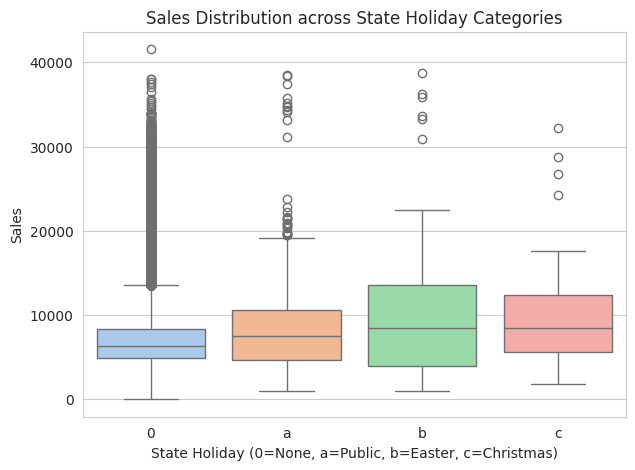

In [18]:
# Graph 6: Effect of State Holiday on Sales
plt.figure(figsize=(7, 5))
sns.boxplot(x="StateHoliday", y="Sales", data=df, palette="pastel")
plt.title("Sales Distribution across State Holiday Categories")
plt.xlabel("State Holiday (0=None, a=Public, b=Easter, c=Christmas)")
plt.ylabel("Sales")
plt.show()

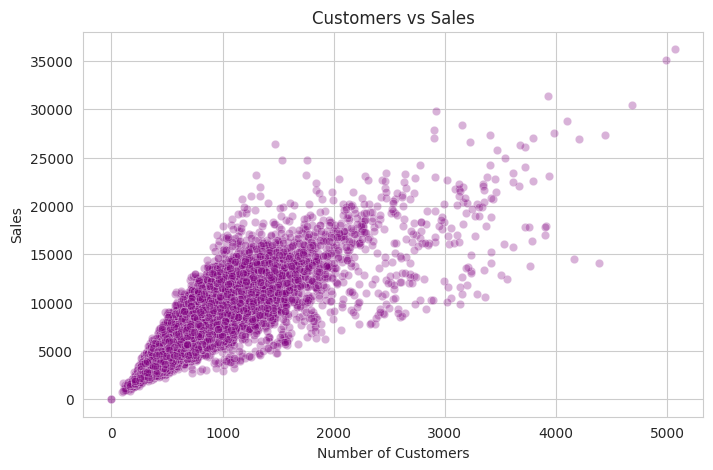

In [19]:
# Graph 7: Relationship between Customers and Sales
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Customers", y="Sales", data=df.sample(20000, random_state=42), alpha=0.3, color="purple")
plt.title("Customers vs Sales")
plt.xlabel("Number of Customers")
plt.ylabel("Sales")
plt.show()

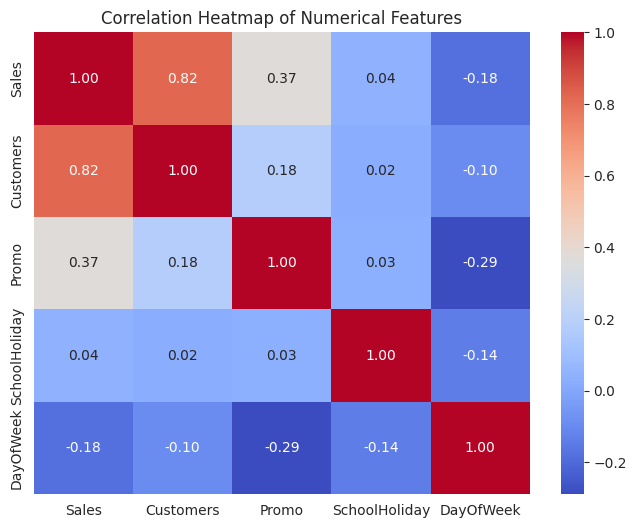

In [20]:
# Graph 8: Correlation heatmap of numerical features
plt.figure(figsize=(8, 6))
numeric_cols = df[["Sales", "Customers", "Promo", "SchoolHoliday", "DayOfWeek"]]
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## 6. Data Pre-processing and Feature Engineering for Models

In [21]:
# Extract temporal features from the Date column
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

# Preview the newly created temporal features
df[["Date", "Year", "Month", "Day", "WeekOfYear"]].head()

,Date,Year,Month,Day,WeekOfYear
0,2015-07-31,2015,7,31,31
1,2015-07-31,2015,7,31,31
2,2015-07-31,2015,7,31,31
3,2015-07-31,2015,7,31,31
4,2015-07-31,2015,7,31,31


In [22]:
# Encode StateHoliday categorical labels into numeric codes
state_holiday_map = {"0": 0, "a": 1, "b": 2, "c": 3}
df["StateHoliday"] = df["StateHoliday"].map(state_holiday_map)

# Confirm encoding applied correctly
df["StateHoliday"].unique()

array([0, 1, 2, 3])

In [23]:
# Drop columns not required for modelling
# Date        -> already decomposed into Year, Month, Day, WeekOfYear
# Customers    -> not known in advance, so excluded to avoid data leakage
# Open         -> constant (1) after filtering, provides no predictive value
df_model = df.drop(columns=["Date", "Customers", "Open"])

# Confirm final feature set
df_model.columns

Index(['Store', 'DayOfWeek', 'Sales', 'Promo', 'StateHoliday', 'SchoolHoliday',
       'Year', 'Month', 'Day', 'WeekOfYear'],
      dtype='object')

In [24]:
# Separate features (X) and target variable (y)
X = df_model.drop(columns=["Sales"])
y = df_model["Sales"]

# Confirm shapes
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (844392, 9)
Target vector shape: (844392,)


In [25]:
# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Confirm split sizes
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 675513
Testing set size: 168879


## 7. Model 1: Linear Regression

In [26]:
# Load / initialize the Linear Regression model
lr_model = LinearRegression()

In [27]:
# Train the Linear Regression model on the training data
lr_model.fit(X_train, y_train)

LinearRegression()

In [28]:
# Generate predictions on the test data
lr_predictions = lr_model.predict(X_test)

In [29]:
# Evaluate Linear Regression performance
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_mape = mean_absolute_percentage_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance")
print("MAE  :", lr_mae)
print("RMSE :", lr_rmse)
print("MAPE :", lr_mape)
print("R2   :", lr_r2)

Linear Regression Performance
MAE  : 2072.205794790749
RMSE : 2864.0835364179447
MAPE : 2294924793555411.0
R2   : 0.14940104001768895


### Linear Regression: Actual vs. Predicted Sales

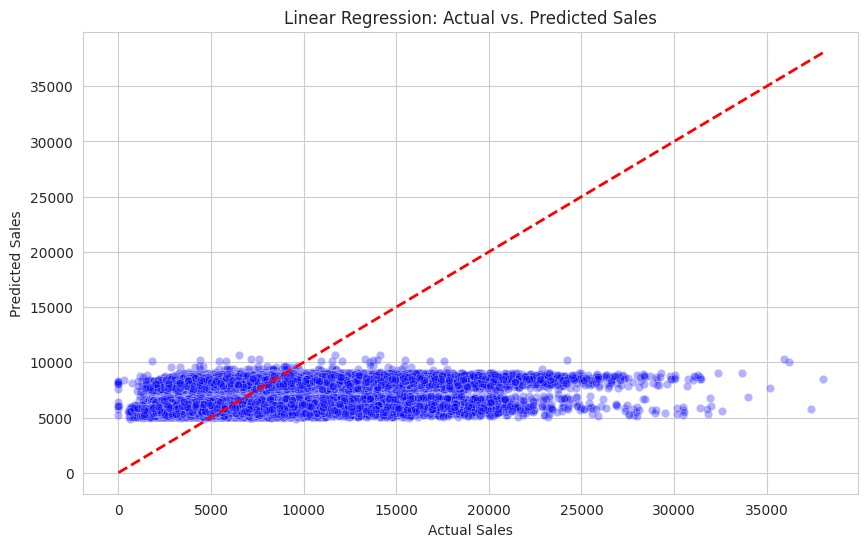

In [47]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=lr_predictions, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression: Actual vs. Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()

## 8. Model 2: Decision Tree Regressor

In [30]:
# Load / initialize the Decision Tree model
dt_model = DecisionTreeRegressor(max_depth=12, random_state=42)

In [31]:
# Train the Decision Tree model on the training data
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=12, random_state=42)

In [32]:
# Generate predictions on the test data
dt_predictions = dt_model.predict(X_test)

In [33]:
# Evaluate Decision Tree performance
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))
dt_mape = mean_absolute_percentage_error(y_test, dt_predictions)
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Performance")
print("MAE  :", dt_mae)
print("RMSE :", dt_rmse)
print("MAPE :", dt_mape)
print("R2   :", dt_r2)

Decision Tree Performance
MAE  : 1906.543443374082
RMSE : 2630.461121827129
MAPE : 2159987598479450.8
R2   : 0.28250767412899924


### Decision Tree: Actual vs. Predicted Sales

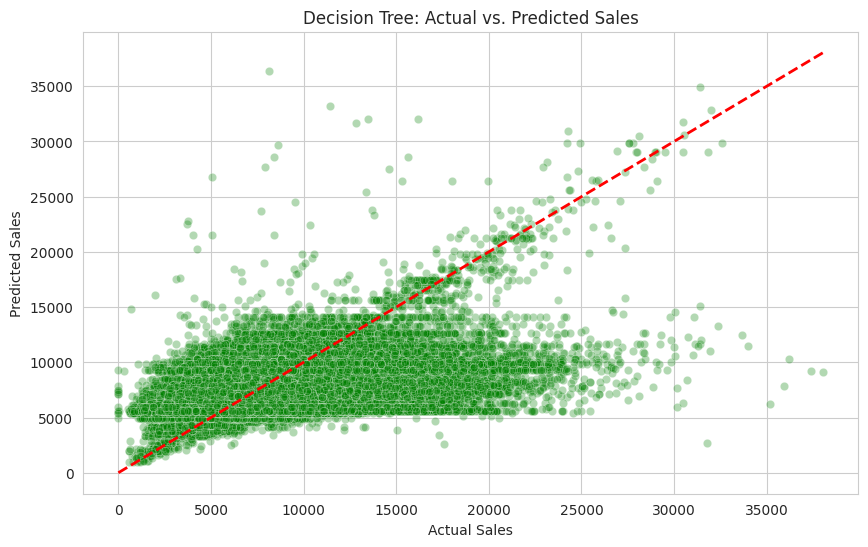

In [48]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=dt_predictions, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Decision Tree: Actual vs. Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()

## 9. Model 3: Random Forest Regressor

In [34]:
# Load / initialize the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

In [35]:
# Train the Random Forest model on the training data
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_jobs=-1, random_state=42)

In [36]:
# Generate predictions on the test data
rf_predictions = rf_model.predict(X_test)

In [37]:
# Evaluate Random Forest performance
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_mape = mean_absolute_percentage_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("MAE  :", rf_mae)
print("RMSE :", rf_rmse)
print("MAPE :", rf_mape)
print("R2   :", rf_r2)

Random Forest Performance
MAE  : 1818.2270692614595
RMSE : 2499.3063683033038
MAPE : 2183431712427309.5
R2   : 0.35227228917807374


### Random Forest: Actual vs. Predicted Sales

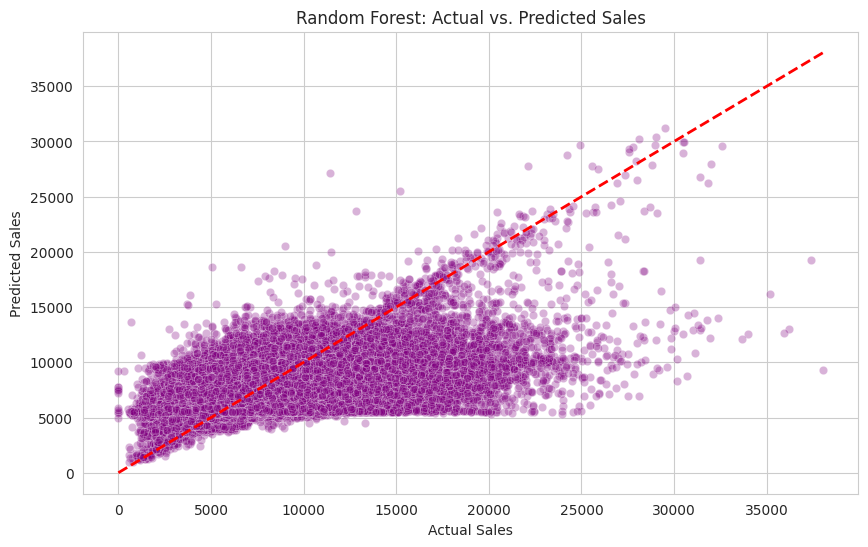

In [49]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=rf_predictions, alpha=0.3, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: Actual vs. Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()

## 10. Model 4: XGBoost Regressor

In [38]:
# Load / initialize the XGBoost model
xgb_model = XGBRegressor(n_estimators=200, max_depth=8, learning_rate=0.1, random_state=42, n_jobs=-1)

In [39]:
# Train the XGBoost model on the training data
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [40]:
# Generate predictions on the test data
xgb_predictions = xgb_model.predict(X_test)

In [41]:
# Evaluate XGBoost performance
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_mape = mean_absolute_percentage_error(y_test, xgb_predictions)
xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost Performance")
print("MAE  :", xgb_mae)
print("RMSE :", xgb_rmse)
print("MAPE :", xgb_mape)
print("R2   :", xgb_r2)

XGBoost Performance
MAE  : 1756.10986328125
RMSE : 2404.211305189292
MAPE : 2416852722515968.0
R2   : 0.40062475204467773


### XGBoost: Actual vs. Predicted Sales

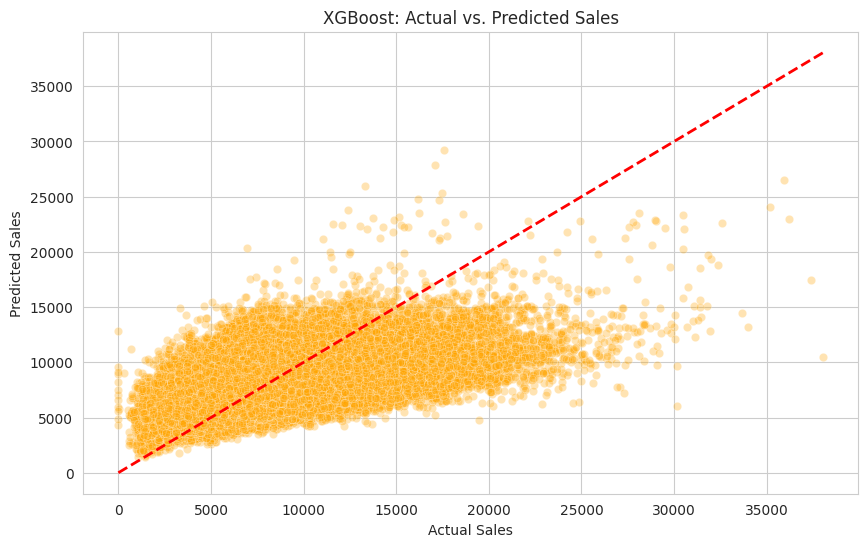

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=xgb_predictions, alpha=0.3, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('XGBoost: Actual vs. Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()

## 11. Model Comparison

In [42]:
# Build a comparison table of all evaluation metrics for the four models
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "MAE": [lr_mae, dt_mae, rf_mae, xgb_mae],
    "RMSE": [lr_rmse, dt_rmse, rf_rmse, xgb_rmse],
    "MAPE": [lr_mape, dt_mape, rf_mape, xgb_mape],
    "R2 Score": [lr_r2, dt_r2, rf_r2, xgb_r2]
})

# Display the comparison table
comparison_df

,Model,MAE,RMSE,MAPE,R2 Score
0,Linear Regression,2072.205795,2864.083536,2.294925e+15,0.149401
1,Decision Tree,1906.543443,2630.461122,2.159988e+15,0.282508
2,Random Forest,1818.227069,2499.306368,2.183432e+15,0.352272
3,XGBoost,1756.109863,2404.211305,2.416853e+15,0.400625


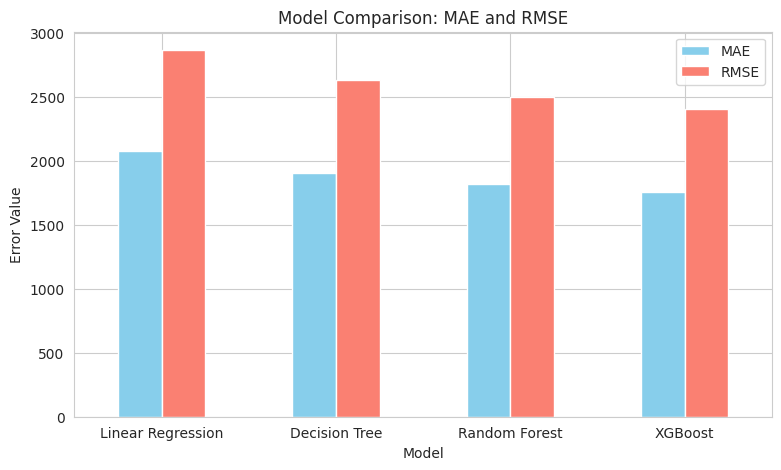

In [43]:
# Graph: Compare MAE and RMSE across models
comparison_df.plot(x="Model", y=["MAE", "RMSE"], kind="bar", figsize=(9, 5), color=["skyblue", "salmon"])
plt.title("Model Comparison: MAE and RMSE")
plt.ylabel("Error Value")
plt.xticks(rotation=0)
plt.show()

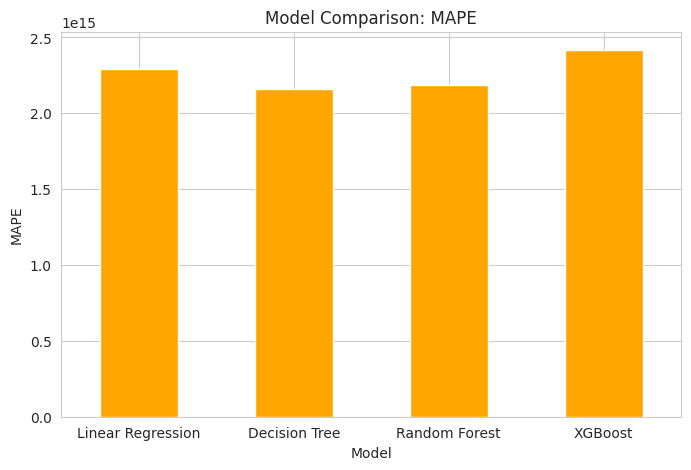

In [44]:
# Graph: Compare MAPE across models
comparison_df.plot(x="Model", y="MAPE", kind="bar", figsize=(8, 5), color="orange", legend=False)
plt.title("Model Comparison: MAPE")
plt.ylabel("MAPE")
plt.xticks(rotation=0)
plt.show()

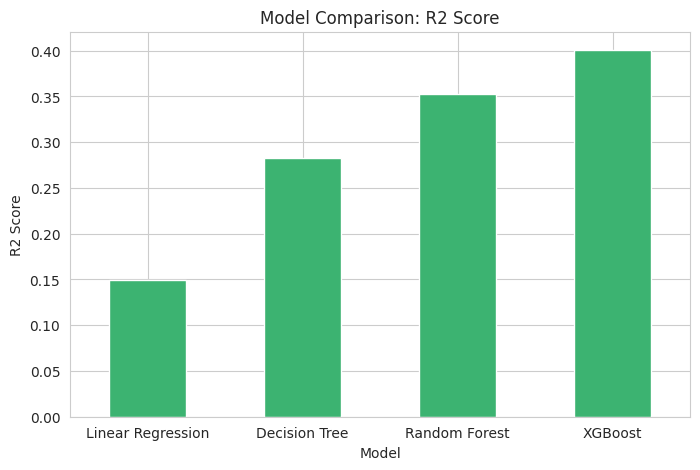

In [45]:
# Graph: Compare R2 Score across models
comparison_df.plot(x="Model", y="R2 Score", kind="bar", figsize=(8, 5), color="mediumseagreen", legend=False)
plt.title("Model Comparison: R2 Score")
plt.ylabel("R2 Score")
plt.xticks(rotation=0)
plt.show()

## 12. Sales Forecasting with the Best Model

In [46]:
# Identify the best performing model based on the highest R2 Score
best_model_row = comparison_df.sort_values(by="R2 Score", ascending=False).iloc[0]

print("Best Performing Model:", best_model_row["Model"])
print("R2 Score :", best_model_row["R2 Score"])
print("MAE      :", best_model_row["MAE"])
print("RMSE     :", best_model_row["RMSE"])
print("MAPE     :", best_model_row["MAPE"])

Best Performing Model: XGBoost
R2 Score : 0.40062475204467773
MAE      : 1756.10986328125
RMSE     : 2404.211305189292
MAPE     : 2416852722515968.0


### 12.1 Prepare Future Data for Forecasting

In [ ]:
# Create a DataFrame with future dates for a specific store (e.g., Store 1)
last_date = df['Date'].max()
future_dates = pd.date_range(start=last_date, periods=30, freq='D') # Forecast for the next 30 days

# Prepare future features, assuming constant or simple patterns for promo, holiday, etc.
future_df = pd.DataFrame({'Date': future_dates})
future_df['Store'] = 1 # Forecasting for Store 1 as an example
future_df['DayOfWeek'] = future_df['Date'].dt.dayofweek + 1 # Monday=1, Sunday=7
future_df['Promo'] = 0 # Assuming no promo for future dates for simplicity
future_df['StateHoliday'] = 0 # Assuming no state holiday for simplicity
future_df['SchoolHoliday'] = 0 # Assuming no school holiday for simplicity
future_df['Year'] = future_df['Date'].dt.year
future_df['Month'] = future_df['Date'].dt.month
future_df['Day'] = future_df['Date'].dt.day
future_df['WeekOfYear'] = future_df['Date'].dt.isocalendar().week.astype(int)

# Drop the 'Date' column as it's not a feature for the model
X_future = future_df.drop(columns=['Date'])

print("Future data for forecasting:")
print(X_future.head())

Future data for forecasting:
   Store  DayOfWeek  Promo  StateHoliday  SchoolHoliday  Year  Month  Day  \
0      1          5      0             0              0  2015      7   31   
1      1          6      0             0              0  2015      8    1   
2      1          7      0             0              0  2015      8    2   
3      1          1      0             0              0  2015      8    3   
4      1          2      0             0              0  2015      8    4   

   WeekOfYear  
0          31  
1          31  
2          31  
3          32  
4          32  


### 12.2 Generate Forecasts using XGBoost

In [ ]:
# Generate forecasts using the best performing model (XGBoost)
xgb_forecasts = xgb_model.predict(X_future)

# Ensure predictions are non-negative
xgb_forecasts[xgb_forecasts < 0] = 0

# Add forecasts to the future_df
future_df['Forecasted_Sales'] = xgb_forecasts

print("XGBoost Forecasts:")
print(future_df[['Date', 'Forecasted_Sales']].head())

XGBoost Forecasts:
        Date  Forecasted_Sales
0 2015-07-31       7059.501465
1 2015-08-01       5795.310059
2 2015-08-02      10911.164062
3 2015-08-03       6953.738770
4 2015-08-04       6141.856445


### 12.3 Visualize the Forecasts

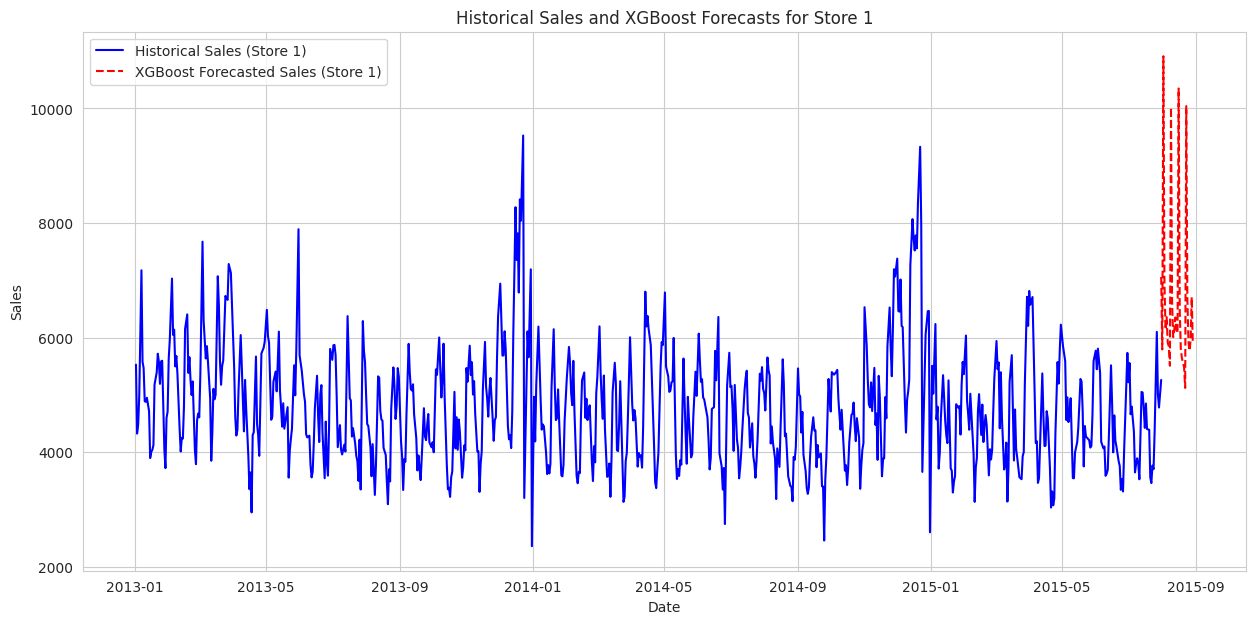

In [ ]:
# Visualize historical sales and future forecasts
plt.figure(figsize=(15, 7))
plt.plot(df[df['Store'] == 1].groupby('Date')['Sales'].sum().index,
         df[df['Store'] == 1].groupby('Date')['Sales'].sum().values,
         label='Historical Sales (Store 1)', color='blue')
plt.plot(future_df['Date'], future_df['Forecasted_Sales'],
         label='XGBoost Forecasted Sales (Store 1)', color='red', linestyle='--')
plt.title('Historical Sales and XGBoost Forecasts for Store 1')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()